In [3]:
# main.py
import QuantLib as ql
import pandas as pd
import numpy as np
from datetime import datetime
from data_processor import HestonDataProcessor
from model_calibrator import HestonParameterSet, run_daily_calibration
import random
import pickle
from typing import Union, Dict, List, Tuple
# ql.FdmSchemeDesc.Douglas()
# ql.FdHestonVanillaEngine


In [4]:
import os
import time
from datetime import datetime

from pandas.core.frame import DataFrame
import akshare as ak
from data_processor import HestonDataProcessor
from model_calibrator import HestonParameterSet, run_daily_calibration
from typing import Optional
def fetch_and_save_yield_curve(start_date: str, end_date: str, csv_path: str) -> Optional[pd.DataFrame]:
    """
    获取中债国债收益率曲线并保存。
    如果本地已存在该文件，则直接读取以节省时间和防止API限流。
    """
    if os.path.exists("..\\data\\"+csv_path):
        print(f"本地已存在利率数据文件: {csv_path}，直接读取。")
        rate_df = pd.read_csv(csv_path, parse_dates=['date'])
        return rate_df

    print(f"开始从 AkShare 获取 {start_date} 到 {end_date} 的国债收益率数据...")
    # 获取中债国债收益率历史数据 (通常包含 3月, 6月, 1年等)
 
    try:
       
        raw_df = ak.bond_china_yield(start_date=start_date.replace("-", ""), end_date=end_date.replace("-", ""))
        
        # 数据清洗：提取我们需要的期限 (转换为年)

        rate_df = pd.DataFrame()
        rate_df['date'] = pd.to_datetime(raw_df['日期'])
        rate_df[0.25] = raw_df['3月'] / 100.0  # 3个月
        rate_df[0.5]  = raw_df['6月'] / 100.0  # 6个月
        rate_df[1.0]  = raw_df['1年'] / 100.0    # 1年
        
        rate_df.to_csv("..\\data\\"+csv_path, index=False)
        print(f"利率数据获取成功，已保存至 {csv_path}")
        return rate_df
    except Exception as e:
        print(f"获取利率数据失败，原因: {e}")
        
        return None

RATE_CSV = "treasury_rates_history.csv"

# 设置需要研究的时间段
START_DATE_STR = "2025-01-01"
END_DATE_STR = "2025-12-30"

# 获取动态利率数据

historical_rate_df: pd.DataFrame|None = fetch_and_save_yield_curve(START_DATE_STR, END_DATE_STR, "..\\data\\"+RATE_CSV)


本地已存在利率数据文件: ..\data\treasury_rates_history.csv，直接读取。


In [3]:


# 初始参数猜测
initial_params = HestonParameterSet(
    v0=0.1, kappa=2.0, theta=0.05, sigma=1, rho=-0.02
)

# 校准
processor = HestonDataProcessor(
    option_csv_path="..\\data\\io_options_processed.csv",
    dividend_csv_path="..\\data\\沪深300_股息率_市值加权_3年_20260408_024105.csv",
    rate_df=historical_rate_df  
)
processor.load_and_clean_data()

start_eval_date = datetime(2025, 1, 1)
end_eval_date = datetime(2025, 12, 31)

print(f"开始运行自 {start_eval_date.date()} 至 {end_eval_date.date()} 的校准...")
params_df = run_daily_calibration(processor, start_eval_date, end_eval_date, initial_params)

if params_df.empty:
    raise Exception("警告：没有任何一天校准成功，请检查数据或校准逻辑")

params_df.to_csv("..\\output\\calibrated_params_daily.csv", index=False)
print(f"校准完成，共 {len(params_df)} 天数据")

# 保存 processor 对象
with open("processor.pkl", "wb") as f:
    pickle.dump(processor, f)
    print("已保存序列化后的训练数据")

流动性过滤后: 22525 条（过滤前 52071 条）
Delta 过滤后: 17897 条（过滤前 52071 条）
开始运行自 2025-01-01 至 2025-12-31 的校准...

[DEBUG] 原始数据行数: 102, 筛选后 helpers: 102
全局优化开始，期权数量: 102
校准完成 2025-01-02 00:00:00: RMSE=9.1107, MAE=6.8249, 状态=ok

[DEBUG] 原始数据行数: 90, 筛选后 helpers: 90
全局优化开始，期权数量: 90
校准完成 2025-01-03 00:00:00: RMSE=11.2775, MAE=8.8096, 状态=ok

[DEBUG] 原始数据行数: 86, 筛选后 helpers: 86
全局优化开始，期权数量: 86
校准完成 2025-01-06 00:00:00: RMSE=7.6638, MAE=5.4439, 状态=ok

[DEBUG] 原始数据行数: 67, 筛选后 helpers: 67
全局优化开始，期权数量: 67
校准完成 2025-01-07 00:00:00: RMSE=5.7838, MAE=4.1678, 状态=ok

[DEBUG] 原始数据行数: 71, 筛选后 helpers: 71
全局优化开始，期权数量: 71
校准完成 2025-01-08 00:00:00: RMSE=7.6768, MAE=5.7684, 状态=ok

[DEBUG] 原始数据行数: 48, 筛选后 helpers: 48
全局优化开始，期权数量: 48
校准完成 2025-01-09 00:00:00: RMSE=7.3967, MAE=5.3179, 状态=ok

[DEBUG] 原始数据行数: 46, 筛选后 helpers: 46
全局优化开始，期权数量: 46
校准完成 2025-01-10 00:00:00: RMSE=8.9365, MAE=6.3506, 状态=ok

[DEBUG] 原始数据行数: 71, 筛选后 helpers: 71
全局优化开始，期权数量: 71
校准完成 2025-01-13 00:00:00: RMSE=9.2692, MAE=6.8891, 状态=ok

[DEBUG] 原始数据行数: 7

In [5]:


finite_rmse = params_df['rmse'][np.isfinite(params_df['rmse'])]
finite_mae  = params_df['mae'][np.isfinite(params_df['mae'])]

print("平均校准误差 - RMSE: {:.4f}, MAE: {:.4f}".format(
    finite_rmse.mean(), finite_mae.mean()
))

平均校准误差 - RMSE: 9.6095, MAE: 7.0987


In [5]:
# 读取训练数据
with open("processor.pkl", "rb") as f:
    processor = pickle.load(f)

start_eval_date = datetime(2025, 1, 1)
end_eval_date = datetime(2025, 12, 31)
initial_params = HestonParameterSet(
    v0=0.005017, kappa=1.3916, theta=0.55, sigma=0.24, rho=0.06
)


In [6]:
from pricing_verification import compare_pricing_on_date
from greeks_analysis import analyze_greeks_dynamics
from datetime import datetime

# 4. 指定代表日期：2025-04-01
date_str = "2025-04-01"
example_date = datetime.strptime(date_str, "%Y-%m-%d")
params_df = pd.read_csv("../output/calibrated_params_daily.csv", parse_dates=['date'])
# 从校准结果中获取该日的 Heston 参数
date_mask = params_df['date'] == pd.Timestamp(example_date)
if date_mask.sum() == 0:
    raise ValueError(f"未找到日期 {example_date} 的校准参数，请检查 params_df")
best_row = params_df[date_mask].iloc[0]

params_example = HestonParameterSet(
    v0=float(best_row['v0']),
    kappa=float(best_row['kappa']),
    theta=float(best_row['theta']),
    sigma=float(best_row['sigma']),
    rho=float(best_row['rho'])
)


In [7]:


print(f"代表日期: {example_date}, RMSE={best_row['rmse']:.4f}，v0={params_example.v0:.4f}, kappa={params_example.kappa:.4f}, theta={params_example.theta:.4f}, sigma={params_example.sigma:.4f}, rho={params_example.rho:.4f}")
comparison_df = compare_pricing_on_date(example_date, processor, params_example,
                                        calibration_csv='calibration_options.csv')
if comparison_df is not None:
    comparison_df.to_csv(f"{date_str}-pricing_comparison.csv", index=False)
    print("定价对比表已保存")
    
    # 计算各模型的平均绝对误差
    if 'market' in comparison_df.columns and 'Heston_analytic' in comparison_df.columns:
        mae_analytic = (comparison_df['Heston_analytic'] - comparison_df['market']).abs().mean()
        print(f"Heston 半解析模型平均绝对误差: {mae_analytic:.4f}")
    if 'Heston_MC' in comparison_df.columns:
        mae_mc = (comparison_df['Heston_MC'] - comparison_df['market']).abs().mean()
        print(f"Heston MC 模型平均绝对误差: {mae_mc:.4f}")
    if 'BS_const' in comparison_df.columns:
        mae_bs_const = (comparison_df['BS_const'] - comparison_df['market']).abs().mean()
        print(f"BS‑Const (平值IV) 平均绝对误差: {mae_bs_const:.4f}")
else:
    print(f"警告：日期 {date_str} 没有可用的期权数据，无法进行定价验证")





代表日期: 2025-04-01 00:00:00, RMSE=5.8319，v0=0.0209, kappa=3.1203, theta=0.0394, sigma=0.4961, rho=0.2274

===== 定价验证 (基于保存的校准期权数据) =====
评估日: 2025-04-01 00:00:00
校准参数: v0=0.020873, kappa=3.1203, theta=0.039441, sigma=0.4961, rho=0.2274
载入当日校准期权数量: 50
标的资产价格: 3887.68
BS‑Const 固定波动率: 0.1501
[1/50] 正在定价: strike=3750.0, type=P
strike=3750.0, type=P, market=7.80,Heston_analytic=7.49, BS_const=8.68, Heston_MC=7.36
T=0.0466, r=0.015200, q=0.032370, F=3884.57
[2/50] 正在定价: strike=3800.0, type=P
strike=3800.0, type=P, market=16.00,Heston_analytic=16.69, BS_const=18.40, Heston_MC=16.50
T=0.0466, r=0.015200, q=0.032370, F=3884.57
[3/50] 正在定价: strike=3850.0, type=C
strike=3850.0, type=C, market=65.20,Heston_analytic=67.39, BS_const=69.12, Heston_MC=67.38
T=0.0466, r=0.015200, q=0.032370, F=3884.57
[4/50] 正在定价: strike=3850.0, type=P
strike=3850.0, type=P, market=30.20,Heston_analytic=32.85, BS_const=34.57, Heston_MC=32.66
T=0.0466, r=0.015200, q=0.032370, F=3884.57
[5/50] 正在定价: strike=3900.0, type=C
s

In [7]:
# 5. 希腊字母动态分析
from greeks_analysis import OptionSpec
target_option: OptionSpec = {'strike': 3900, 'type': 'C', 'expiry': datetime(2025, 6, 20)}# 选取的期权
fname: str = f"greeks_dynamics_{target_option['type']}{target_option['strike']}_{target_option['expiry'].strftime('%Y%m%d')}.csv"


In [9]:
# 取前110天，但需保证这110天在校准结果中
eval_dates = params_df['date'].head(110).tolist()
if len(eval_dates) < 110 :
    print("警告：校准参数为空，无法进行希腊字母分析")
else:
    greeks_df = analyze_greeks_dynamics(processor, params_df, target_option, eval_dates)
    greeks_df.to_csv(fname, index=False)
    print("希腊字母动态分析完成")
    print(greeks_df.head())

希腊字母动态分析完成
      delta     gamma       theta       rho        vega       date     spot
0  0.380975  0.000759 -187.525912  6.708863  975.522489 2025-01-02  3820.40
1  0.344662  0.000637 -225.521004  5.445228  870.383001 2025-01-03  3775.16
2  0.345772  0.000648 -212.553915  5.267388  760.958381 2025-01-06  3768.97
3  0.360915  0.000704 -220.498957  5.561366  668.505759 2025-01-07  3796.11
4  0.351843  0.000742 -202.650110  5.425285  794.279933 2025-01-08  3789.22


In [10]:
# 对偶变量法方差缩减效果评估
import QuantLib as ql
import pandas as pd
import numpy as np
from model_calibrator import HestonParameterSet
from pricing_verification import HestonMonteCarloPricer

# 选取代表日期和参数
date_str = "2025-04-01"
example_date = pd.Timestamp(date_str)

# 读出校准参数
params_df = pd.read_csv("../output/calibrated_params_daily.csv", parse_dates=['date'])
row = params_df[params_df['date'] == example_date].iloc[0]
params = HestonParameterSet(
    v0=float(row['v0']),
    kappa=float(row['kappa']),
    theta=float(row['theta']),
    sigma=float(row['sigma']),
    rho=float(row['rho'])
)

# 获取市场数据
import pickle
with open("processor.pkl", "rb") as f:
    processor = pickle.load(f)

spot = processor.get_underlying_quote(example_date)
q = processor.get_dividend_yield(example_date)

eval_date_ql = ql.Date(example_date.day, example_date.month, example_date.year)
r_curve = processor._build_rate_curve(example_date)
q_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(eval_date_ql, q, ql.Actual365Fixed())
)

# 选择一个代表性期权（例如 ATM 远期附近的看涨期权）
day_data = processor.get_calibration_data(example_date)
if day_data.empty:
    raise ValueError("校准数据为空")

# 选择 T 适中、流动性好的期权
valid = day_data[(day_data['T'] > 0.1) & (day_data['T'] < 1.0) & (day_data['cp'].str.upper() == 'C')].copy()
if valid.empty:
    valid = day_data[day_data['cp'].str.upper() == 'C']  # 放宽限制

# 选择最接近平值的（|Δ| ~ 0.5 优先）
if 'delta' in valid.columns:
    valid['abs_delta'] = (valid['delta'].abs() - 0.5).abs()
    chosen = valid.loc[valid['abs_delta'].idxmin()]
else:
    chosen = valid.iloc[len(valid)//2]  # 折中选择

strike = float(chosen['strike'])
expiry_date = pd.Timestamp(chosen['expiry'])
opt_type = str(chosen['cp']).upper()
T = float(chosen['T'])

print(f"===== 对偶变量效果评估 =====")
print(f"日期: {example_date.date()}")
print(f"标的: {spot:.2f}, 股息率: {q:.4%}, 期权: {opt_type} {strike}, T={T:.4f}年")
print(f"Heston参数: v0={params.v0:.4f}, kappa={params.kappa:.2f}, theta={params.theta:.4f}, sigma={params.sigma:.4f}, rho={params.rho:.4f}")

# 4. 共用 MC 参数
n_steps = 252
n_paths = 1e7
seed = 42

# 不使用对偶变量
pricer_no_av = HestonMonteCarloPricer(
    params, spot,
    ql.YieldTermStructureHandle(r_curve),
    q_curve,
    eval_date=example_date,
    expiry_date=expiry_date,
    n_steps=n_steps,
    n_paths=n_paths,
    antithetic=False,
    seed=seed
)
price_no, se_no = pricer_no_av.price_with_error(strike, opt_type)

# 使用对偶变量
pricer_av = HestonMonteCarloPricer(
    params, spot,
    ql.YieldTermStructureHandle(r_curve),
    q_curve,
    eval_date=example_date,
    expiry_date=expiry_date,
    n_steps=n_steps,
    n_paths=n_paths,
    antithetic=True,
    seed=seed 
)
price_av, se_av = pricer_av.price_with_error(strike, opt_type)

# 输出比对
print(f"\n--- 不使用对偶变量 ---")
print(f"价格: {price_no:.4f}, 标准误: {se_no:.6f}")
print(f"--- 使用对偶变量 ---")
print(f"价格: {price_av:.4f}, 标准误: {se_av:.6f}")

if se_av > 0 and se_no > 0:
    reduction_ratio = se_no / se_av
    variance_reduction = (se_no**2) / (se_av**2)
    print(f"\n标准误比值 (无对偶/对偶): {reduction_ratio:.2f}")
    print(f"方差缩减比 (无对偶方差 / 对偶方差): {variance_reduction:.2f}")
else:
    print("标准误为零或无效，无法计算缩减比")

# 6. 对比与半解析价格的差异
from pricing_verification import HestonModelPricer
analytic_pricer = HestonModelPricer(params, spot,
                                    ql.YieldTermStructureHandle(r_curve), q_curve)
analytic_price = analytic_pricer.price(opt_type, strike, expiry_date, example_date)
print(f"\n半解析价格 (基准): {analytic_price:.4f}")
print(f"无对偶偏差: {price_no - analytic_price:.4f}")
print(f"对偶偏差:   {price_av - analytic_price:.4f}")

===== 对偶变量效果评估 =====
日期: 2025-04-01
标的: 3887.68, 股息率: 3.2370%, 期权: C 3900.0, T=0.1233年
Heston参数: v0=0.0209, kappa=3.12, theta=0.0394, sigma=0.4961, rho=0.2274

--- 不使用对偶变量 ---
价格: 72.2592, 标准误: 0.149999
--- 使用对偶变量 ---
价格: 72.0369, 标准误: 0.149905

标准误比值 (无对偶/对偶): 1.00
方差缩减比 (无对偶方差 / 对偶方差): 1.00

半解析价格 (基准): 0.0000
无对偶偏差: 72.2592
对偶偏差:   72.0369


In [8]:
# 生成论文图表
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import pandas as pd
import numpy as np
import pickle
from datetime import datetime





加载数据并绘图


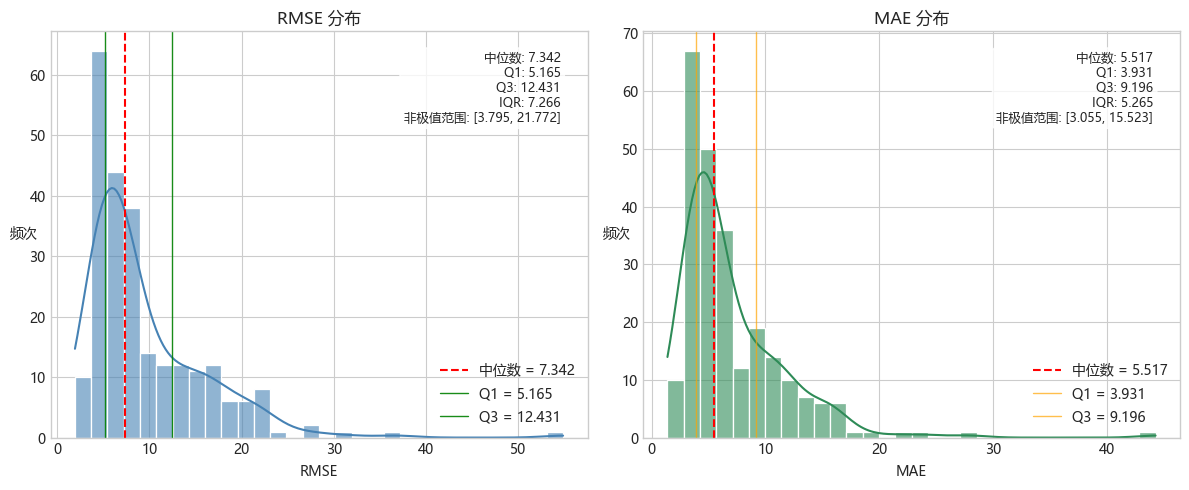

In [8]:
import numpy as np
import pandas as pd
params_df = pd.read_csv("../output/calibrated_params_daily.csv", parse_dates=['date'])
# 清理无效值（NaN 或 inf）
rmse_clean = params_df['rmse'][np.isfinite(params_df['rmse'])]
mae_clean  = params_df['mae'][np.isfinite(params_df['mae'])]

# 创建画布（两个子图）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 绘制 RMSE 分布
sns.histplot(rmse_clean, bins=30, kde=True, ax=axes[0], color='steelblue', alpha=0.6)
axes[0].set_title('RMSE 分布', fontsize=12)
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('频次',verticalalignment='center',rotation=0)
# 使用对数坐标（如果数据跨度过大）
if rmse_clean.max() / rmse_clean.median() > 10:
    axes[0].set_xscale('log')
    axes[0].set_xlabel('RMSE (对数坐标)')

# 统计量
rmse_median = rmse_clean.median()
rmse_q1 = rmse_clean.quantile(0.25)
rmse_q3 = rmse_clean.quantile(0.75)
rmse_iqr = rmse_q3 - rmse_q1

# 在图上标注中位数和四分位范围
axes[0].axvline(rmse_median, color='red', linestyle='--', linewidth=1.5, label=f'中位数 = {rmse_median:.3f}')
axes[0].axvline(rmse_q1, color='green', linestyle='-', linewidth=1, alpha=0.9, label=f'Q1 = {rmse_q1:.3f}')
axes[0].axvline(rmse_q3, color='green', linestyle='-', linewidth=1, alpha=0.9, label=f'Q3 = {rmse_q3:.3f}')
axes[0].legend(loc='lower right')
textstr_rmse = (f'中位数: {rmse_median:.3f}\n'
                f'Q1: {rmse_q1:.3f}\n'
                f'Q3: {rmse_q3:.3f}\n'
                f'IQR: {rmse_iqr:.3f}\n'
                f'非极值范围: [{rmse_clean.quantile(0.05):.3f}, {rmse_clean.quantile(0.95):.3f}]')
axes[0].text(0.95, 0.95, textstr_rmse, transform=axes[0].transAxes,
             fontsize=9, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 绘制 MAE 分布
sns.histplot(mae_clean, bins=30, kde=True, ax=axes[1], color='seagreen', alpha=0.6)
axes[1].set_title('MAE 分布', fontsize=12)
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('频次',verticalalignment='center',rotation=0)
if mae_clean.max() / mae_clean.median() > 10:
    axes[1].set_xscale('log')
    axes[1].set_xlabel('MAE (对数坐标)')

mae_median = mae_clean.median()
mae_q1 = mae_clean.quantile(0.25)
mae_q3 = mae_clean.quantile(0.75)
mae_iqr = mae_q3 - mae_q1

axes[1].axvline(mae_median, color='red', linestyle='--', linewidth=1.5, label=f'中位数 = {mae_median:.3f}')
axes[1].axvline(mae_q1, color='orange', linestyle='-', linewidth=1, alpha=0.7, label=f'Q1 = {mae_q1:.3f}')
axes[1].axvline(mae_q3, color='orange', linestyle='-', linewidth=1, alpha=0.7, label=f'Q3 = {mae_q3:.3f}')
axes[1].legend(loc='lower right')

textstr_mae = (f'中位数: {mae_median:.3f}\n'
               f'Q1: {mae_q1:.3f}\n'
               f'Q3: {mae_q3:.3f}\n'
               f'IQR: {mae_iqr:.3f}\n'
               f'非极值范围: [{mae_clean.quantile(0.05):.3f}, {mae_clean.quantile(0.95):.3f}]')
axes[1].text(0.95, 0.95, textstr_mae, transform=axes[1].transAxes,
             fontsize=9, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("../image/RMSE_MAE_Comparison.pdf", dpi=300)
plt.show()

In [9]:

pricing_df = pd.read_csv(f"{date_str}-pricing_comparison.csv")
greeks_df = pd.read_csv(f"{fname}", parse_dates=['date'])
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

with open("processor.pkl", "rb") as f:
    processor = pickle.load(f)


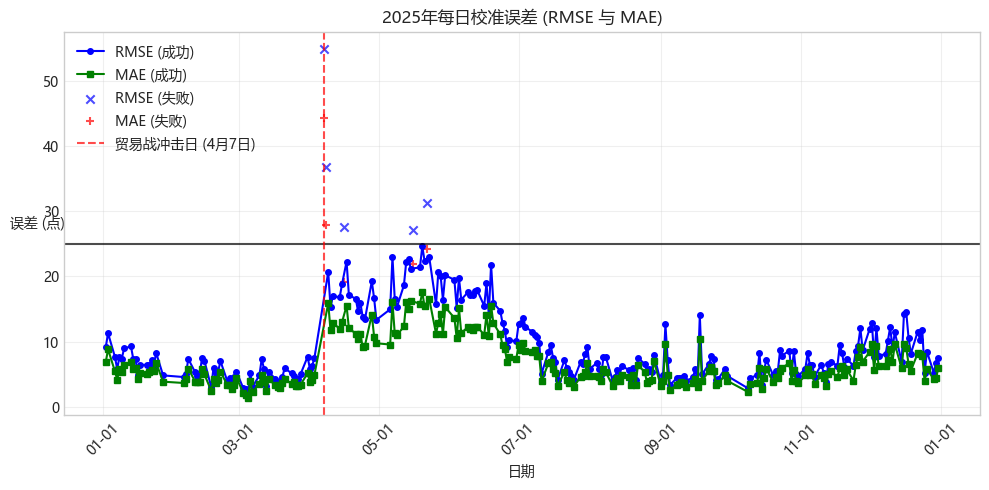

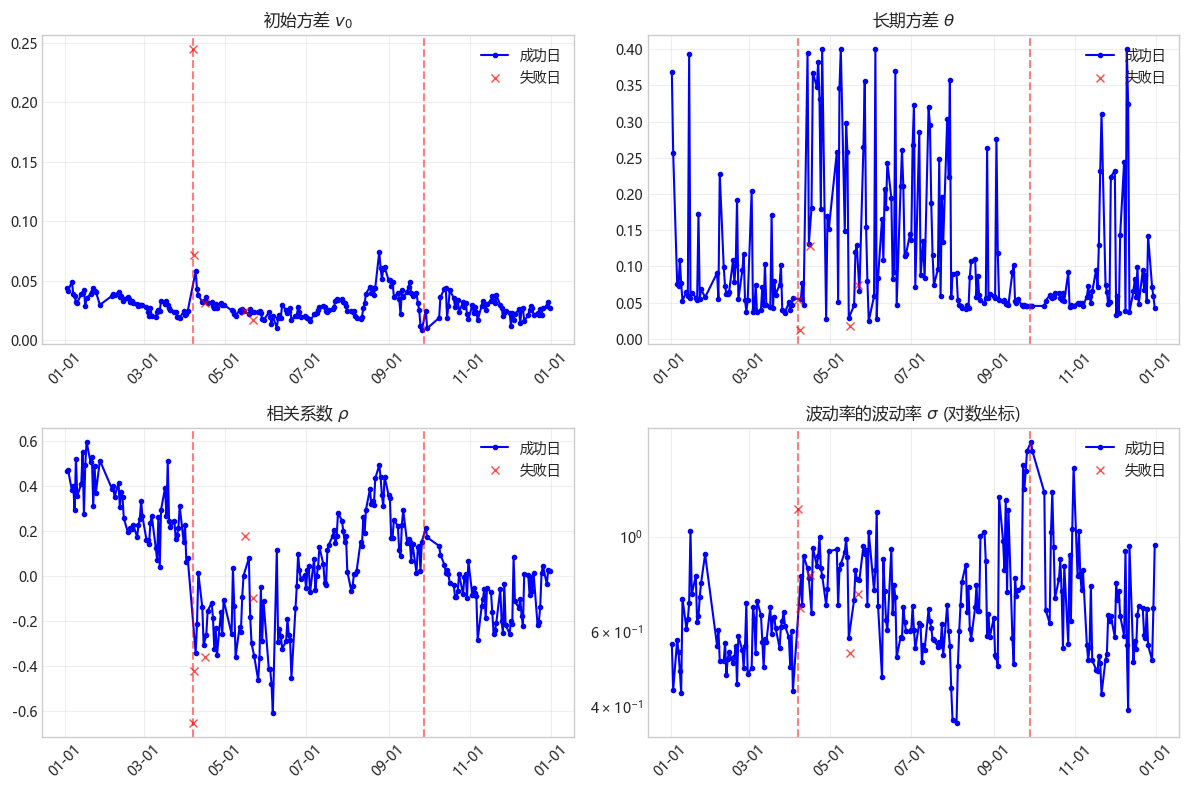

BS 常数波动率: 0.1501


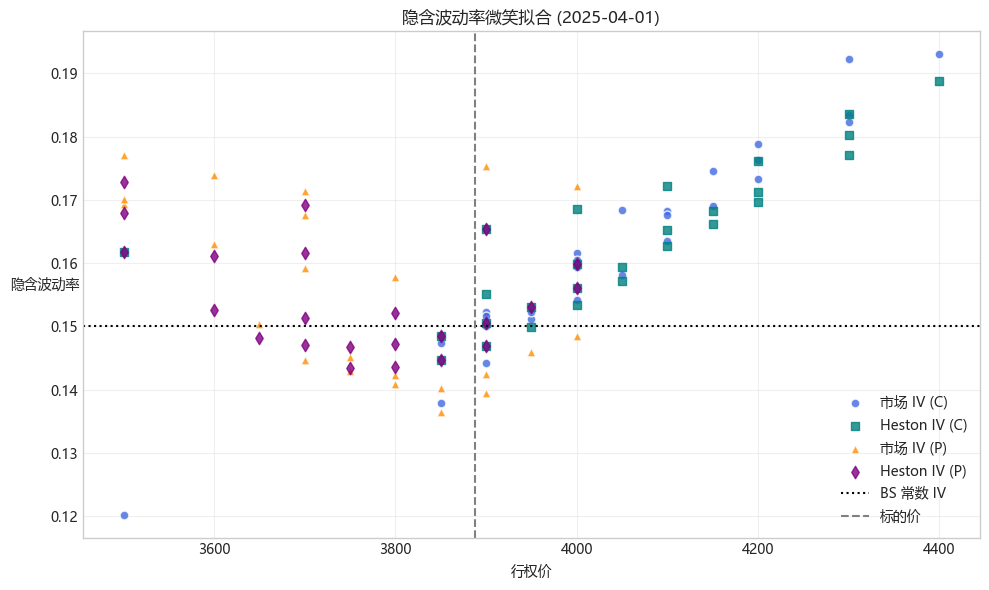

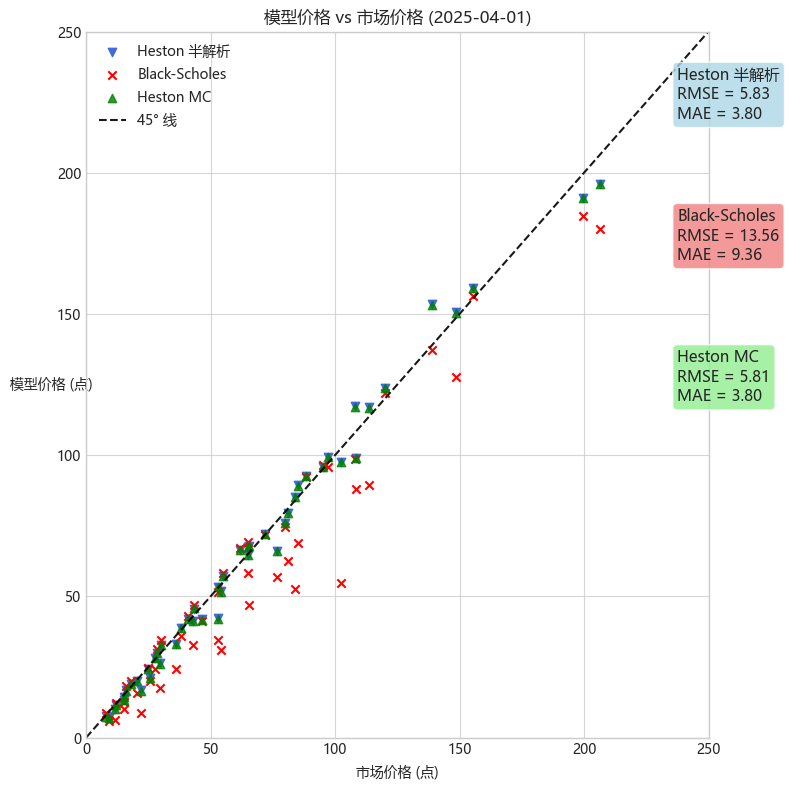

In [23]:



# 校准误差时间序列

fig, ax = plt.subplots(figsize=(10, 5))

# 分离成功与失败日
ok_df = params_df[params_df['status'] == 'ok']
fail_df = params_df[params_df['status'] == 'failed']

# 绘制成功的 RMSE 和 MAE（实线 + 标记）
ax.plot(ok_df['date'], ok_df['rmse'], 'bo-', label='RMSE (成功)', linewidth=1.5, markersize=4)
ax.plot(ok_df['date'], ok_df['mae'], 'gs-', label='MAE (成功)', linewidth=1.5, markersize=4)

# 失败的 RMSE 和 MAE
if not fail_df.empty:
    ax.scatter(fail_df['date'], fail_df['rmse'], marker='x', color='blue', label='RMSE (失败)', alpha=0.7)
    ax.scatter(fail_df['date'], fail_df['mae'], marker='+', color='red', label='MAE (失败)', alpha=0.7)
    ax.axhline(25, color = "black", linewidth=1.5, markersize=6, alpha=0.7)

ax.axvline(pd.Timestamp('2025-04-07'), color='red', linestyle='--', alpha=0.7, label='贸易战冲击日 (4月7日)')
ax.set_xlabel('日期')
ax.set_ylabel('误差 (点)',verticalalignment='center',rotation=0)
ax.set_title('2025年每日校准误差 (RMSE 与 MAE)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../image/fig_calibration_error.pdf', dpi=300)
plt.show()


# 关键参数时间序列（v0, theta, rho, sigma）

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

params_to_plot = [
    ('v0', axes[0], '初始方差 $v_0$'),
    ('theta', axes[1], '长期方差 $\\theta$'),
    ('rho', axes[2], '相关系数 $\\rho$'),
    ('sigma', axes[3], '波动率的波动率 $\\sigma$ (对数坐标)')
]

for param, ax, title in params_to_plot:
    # 成功日
    ax.plot(ok_df['date'], ok_df[param], 'o-', color='blue', markersize=3, label='成功日')
    # 失败日
    if not fail_df.empty:
        ax.plot(fail_df['date'], fail_df[param], 'rx', markersize=6, label='失败日', alpha=0.7)
    ax.axvline(pd.Timestamp('2025-04-07'), color='red', linestyle='--', alpha=0.5)
    ax.axvline(pd.Timestamp('2025-09-28'), color='red', linestyle='--', alpha=0.5)
    if param == 'sigma':
        ax.set_yscale('log')
    ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../image/fig_parameters_time_series.pdf', dpi=300)
plt.show()

#隐含波动率微笑拟合（Heston IV vs 市场 IV）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import QuantLib as ql
from pricing_verification import BlackScholesPricer, HestonModelPricer
from model_calibrator import HestonParameterSet

# 沿用之前的验证日期
date_str = "2025-04-01"
eval_date = pd.Timestamp(date_str)


spot = processor.get_underlying_quote(eval_date)
q = processor.get_dividend_yield(eval_date)

# 获取该日 Heston 参数
row = params_df[params_df['date'] == eval_date].iloc[0]
heston_params = HestonParameterSet(
    v0=float(row['v0']),
    kappa=float(row['kappa']),
    theta=float(row['theta']),
    sigma=float(row['sigma']),
    rho=float(row['rho'])
)


r_curve = processor._build_rate_curve(eval_date)
eval_date_ql = ql.Date(eval_date.day, eval_date.month, eval_date.year)
q_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(eval_date_ql, q, ql.Actual365Fixed())
)
pricer = HestonModelPricer(
    heston_params,
    spot,
    ql.YieldTermStructureHandle(r_curve),
    q_curve
)

def heston_price_to_iv(heston_price, strike, r, q, T, opt_type, spot, eval_date):
    """
    给定 Heston 模型价格，反解出等价的 BS 隐含波动率
    """
    def objective(sigma):
        bs_price = BlackScholesPricer.price(spot, strike, r, q, T, sigma, opt_type)
        return bs_price - heston_price
    try:
        iv = brentq(objective, 1e-6, 3.0)
        return float(iv)
    except Exception:
        return np.nan

# 读取定价对比表（之前 compare_pricing_on_date 保存的文件）
pricing_csv = f"{date_str}-pricing_comparison.csv"
try:
    pricing_df = pd.read_csv(pricing_csv)
except FileNotFoundError:
    # 如果找不到文件，则现场重新计算（注意：这会触发 MC，较慢）
    print("未找到定价对比文件，正在重新计算...")
    from pricing_verification import compare_pricing_on_date
    comparison_df = compare_pricing_on_date(eval_date, processor, heston_params,
                                            calibration_csv='calibration_options.csv')
    pricing_df = comparison_df

# 准备画图数据
market_ivs = []
heston_ivs = []
strikes = []
types = []

for _, row in pricing_df.iterrows():
    # 从定价表中获取信息
    strike = row['strike']
    opt_type = row['type']
    T = row['T']
    market_price = row['market']                   # 市场价格
    heston_price = row['Heston_analytic']          # Heston 半解析价格

    # 计算无风险利率
    r = processor.get_risk_free_rate(T, eval_date)

    # 市场 IV
    try:
        market_iv = brentq(
            lambda sigma: BlackScholesPricer.price(spot, strike, r, q, T, sigma, opt_type) - market_price,
            1e-6, 3.0
        )
    except:
        market_iv = np.nan

    # 从 Heston 模型价格反推隐含波动率
    heston_iv = heston_price_to_iv(heston_price, strike, r, q, T, opt_type, spot, eval_date)

    if np.isfinite(market_iv) and np.isfinite(heston_iv):
        market_ivs.append(market_iv)
        heston_ivs.append(heston_iv)
        strikes.append(strike)
        types.append(opt_type)
        
# 计算 BS 常数波动率（平值 IV）
day_data = processor.get_calibration_data(eval_date)
sigma_const = None
if 'delta' in day_data.columns and day_data['delta'].notna().any():
    atm_idx = (day_data['delta'].abs() - 0.5).abs().idxmin()
    atm_row = day_data.loc[atm_idx]
    if 'bs_iv' in atm_row and pd.notna(atm_row['bs_iv']):
        sigma_const = float(atm_row['bs_iv'])
if sigma_const is None:
    valid_ivs = day_data['bs_iv'].dropna()
    if not valid_ivs.empty:
        sigma_const = float(valid_ivs.median())
if sigma_const is None or sigma_const <= 0:
    sigma_const = float(np.sqrt(max(heston_params.v0, 1e-8)))
print(f"BS 常数波动率: {sigma_const:.4f}")
# 绘图
fig, ax = plt.subplots(figsize=(10, 6))

for t in ['C', 'P']:
    idx = [i for i, _ in enumerate(types) if _ == t]
    if not idx:
        continue
    
    # 颜色配置
    if t == 'C':
        market_color = 'royalblue'
        heston_color = 'teal'
        marker_market = 'o'
        marker_heston = 's'
    else:  # Put
        market_color = 'darkorange'
        heston_color = 'purple'
        marker_market = '^'
        marker_heston = 'd'
    
    ax.scatter([strikes[i] for i in idx], [market_ivs[i] for i in idx],
               label=f'市场 IV ({t})', marker=marker_market, s=40,
               color=market_color, alpha=0.8, edgecolors='white')
    ax.scatter([strikes[i] for i in idx], [heston_ivs[i] for i in idx],
               label=f'Heston IV ({t})', marker=marker_heston, s=40,
               color=heston_color, alpha=0.8)
# 画 BS 常数波动率水平线
ax.axhline(y=sigma_const, color='black', linestyle=':', linewidth=1.5, label='BS 常数 IV')
ax.axvline(spot, color='gray', linestyle='--', label='标的价')
ax.set_xlabel('行权价')
ax.set_ylabel('隐含波动率', verticalalignment='center', rotation=0)
ax.set_title(f'隐含波动率微笑拟合 ({date_str})')
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../image/fig_iv_smile.pdf', dpi=300)
plt.show()


#模型价格 vs 市场价格散点图

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pricing_df['market'], pricing_df['Heston_analytic'], label='Heston 半解析', marker="v",alpha=1, color='royalblue')
ax.scatter(pricing_df['market'], pricing_df['BS_const'], label='Black-Scholes', alpha=1, marker='x',color="r")
ax.scatter(pricing_df['market'], pricing_df['Heston_MC'],
           label='Heston MC', marker='^', alpha=0.8, color='green')
ax.plot([0, 250], [0, 250], 'k--', alpha=0.9, label='45° 线')
ax.set_xlabel('市场价格 (点)')
ax.set_ylabel('模型价格 (点)',verticalalignment='center',rotation=0)
ax.set_title('模型价格 vs 市场价格 (2025-04-01)')
ax.legend()
ax.grid(True, alpha=0.8)
ax.set_xlim(0, 250)
ax.set_ylim(0, 250)
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 计算 Heston 半解析的误差
rmse_heston = np.sqrt(mean_squared_error(pricing_df['market'], pricing_df['Heston_analytic']))
mae_heston  = mean_absolute_error(pricing_df['market'], pricing_df['Heston_analytic'])
# 计算 Black-Scholes (BS‑const) 的误差
rmse_bs = np.sqrt(mean_squared_error(pricing_df['market'], pricing_df['BS_const']))
mae_bs  = mean_absolute_error(pricing_df['market'], pricing_df['BS_const'])

rmse_mc = np.sqrt(mean_squared_error(pricing_df['market'], pricing_df['Heston_MC']))
mae_mc = mean_absolute_error(pricing_df['market'], pricing_df['Heston_MC'])
ax.text(0.95, 0.55, f'Heston MC\nRMSE = {rmse_mc:.2f}\nMAE = {mae_mc:.2f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
# 在图上添加文本
# Heston 误差放在左上角
ax.text(0.95, 0.95, f'Heston 半解析\nRMSE = {rmse_heston:.2f}\nMAE = {mae_heston:.2f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# BS 误差放在左上角 Heston 下方（或右边）
ax.text(0.95, 0.75, f'Black-Scholes\nRMSE = {rmse_bs:.2f}\nMAE = {mae_bs:.2f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
plt.tight_layout()
plt.savefig('../image/fig_price_scatter.pdf', dpi=300)
plt.show()



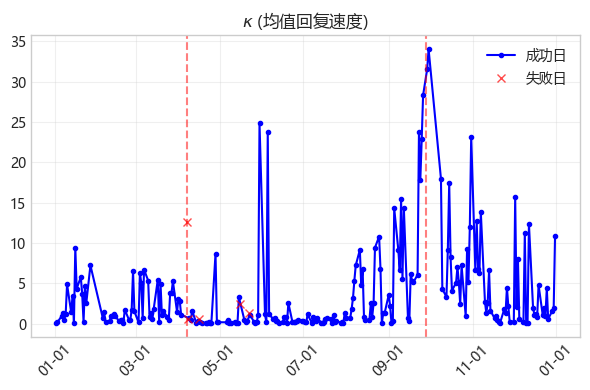

In [23]:

# 单独绘制 kappa 参数的时间序列

fig_k, ax_k = plt.subplots(figsize=(6, 4))  # 与子图大小一致 (12,8) / (2,2) ≈ (6,4)

ax_k.plot(ok_df['date'], ok_df['kappa'], 'o-', color='blue', markersize=3, label='成功日')
if not fail_df.empty:
    ax_k.plot(fail_df['date'], fail_df['kappa'], 'rx', markersize=6, label='失败日', alpha=0.7)
ax_k.axvline(pd.Timestamp('2025-04-07'), color='red', linestyle='--', alpha=0.5)
ax_k.axvline(pd.Timestamp('2025-09-28'), color='red', linestyle='--', alpha=0.5)

ax_k.set_title(r'$\kappa$ (均值回复速度)')
ax_k.legend(loc='best')
ax_k.grid(True, alpha=0.3)
ax_k.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax_k.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../image/fig_kappa_time_series.pdf', dpi=300)
plt.show()

bs 模型 mae rmse

2025-01-02: BS RMSE=18.79, MAE=15.05
2025-01-03: BS RMSE=17.82, MAE=12.66
2025-01-06: BS RMSE=14.38, MAE=10.42
2025-01-07: BS RMSE=12.07, MAE=10.23
2025-01-08: BS RMSE=15.44, MAE=10.77
2025-01-09: BS RMSE=20.79, MAE=12.93
2025-01-10: BS RMSE=20.65, MAE=15.70
2025-01-13: BS RMSE=15.18, MAE=13.12
2025-01-14: BS RMSE=17.01, MAE=14.62
2025-01-15: BS RMSE=18.19, MAE=12.80
2025-01-16: BS RMSE=22.33, MAE=17.20
2025-01-17: BS RMSE=17.23, MAE=14.61
2025-01-20: BS RMSE=18.51, MAE=13.16
2025-01-21: BS RMSE=14.34, MAE=12.03
2025-01-22: BS RMSE=15.37, MAE=11.16
2025-01-23: BS RMSE=27.25, MAE=20.90
2025-01-24: BS RMSE=15.27, MAE=12.69
2025-01-27: BS RMSE=19.22, MAE=12.90
2025-02-05: BS RMSE=20.44, MAE=13.71
2025-02-06: BS RMSE=18.94, MAE=13.37
2025-02-07: BS RMSE=13.29, MAE=10.89
2025-02-10: BS RMSE=15.51, MAE=11.01
2025-02-11: BS RMSE=13.96, MAE=9.22
2025-02-12: BS RMSE=9.79, MAE=7.91
2025-02-13: BS RMSE=13.77, MAE=11.13
2025-02-14: BS RMSE=10.95, MAE=8.91
2025-02-17: BS RMSE=8.12, MAE=5.74
2025-02

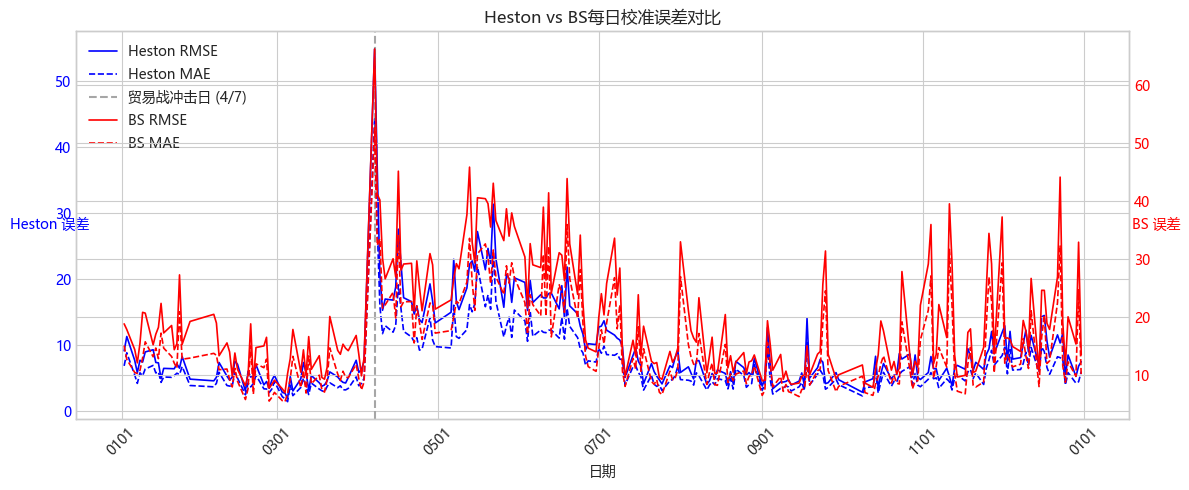


--- 误差统计 ---
Heston RMSE 均值: 9.61, MAE 均值: 7.10
BS RMSE 均值:     19.60, MAE 均值:     14.90


In [10]:

# 计算 Black‑Scholes (平值 IV) 的每日 RMSE/MAE 并与 Heston 对比
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pricing_verification import BlackScholesPricer

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取 Heston 校准结果（已包含 date, rmse, mae, status 等）
params_df = pd.read_csv("../output/calibrated_params_daily.csv", parse_dates=['date'])

# 存储 BS 误差的列表
bs_rmse_list = []
bs_mae_list = []
valid_dates = []

for _, row in params_df.iterrows():
    eval_date = row['date']
    try:
        day_data = processor.get_calibration_data(eval_date)
        if day_data.empty:
            continue

        # 确定 BS 平值波动率
        if 'delta' in day_data.columns and day_data['delta'].notna().any():
            atm_idx = (day_data['delta'].abs() - 0.5).abs().idxmin()
            atm_iv = day_data.loc[atm_idx, 'bs_iv']
            if pd.notna(atm_iv):
                sigma_const = float(atm_iv)
            else:
                sigma_const = float(day_data['bs_iv'].dropna().median())
        else:
            sigma_const = float(day_data['bs_iv'].dropna().median())
        if np.isnan(sigma_const) or sigma_const <= 0:
            continue

        # 计算当日的 BS 价格和误差
        spot = processor.get_underlying_quote(eval_date)
        q = processor.get_dividend_yield(eval_date)
        market_prices = []
        bs_prices = []
        for _, opt in day_data.iterrows():
            T = float(opt['T'])
            r = processor.get_risk_free_rate(T, eval_date)
            bs_price = BlackScholesPricer.price(
                spot, float(opt['strike']), r, q, T, sigma_const,
                str(opt['cp']).upper().strip()
            )
            market_prices.append(float(opt['close']))
            bs_prices.append(bs_price)

        market_prices = np.array(market_prices)
        bs_prices = np.array(bs_prices)
        rmse = np.sqrt(np.mean((market_prices - bs_prices) ** 2))
        mae = np.mean(np.abs(market_prices - bs_prices))
        bs_rmse_list.append(rmse)
        bs_mae_list.append(mae)
        valid_dates.append(eval_date)
        print(f"{eval_date.date()}: BS RMSE={rmse:.2f}, MAE={mae:.2f}", flush=True)
    except Exception as e:
        print(f"{eval_date.date()} 计算失败: {e}")
        continue

bs_error_df = pd.DataFrame({'date': valid_dates, 'bs_rmse': bs_rmse_list, 'bs_mae': bs_mae_list})

# 合并两个数据框，只保留共同日期
compare_df = pd.merge(params_df, bs_error_df, on='date', how='inner')
compare_df = compare_df.sort_values('date')

# 绘图！
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# Heston 误差（左
ax1.plot(compare_df['date'], compare_df['rmse'], 'b-', label='Heston RMSE', linewidth=1.2)
ax1.plot(compare_df['date'], compare_df['mae'], 'b--', label='Heston MAE', linewidth=1.2)
# BS 误差（右
ax2.plot(compare_df['date'], compare_df['bs_rmse'], 'r-', label='BS RMSE', linewidth=1.2)
ax2.plot(compare_df['date'], compare_df['bs_mae'], 'r--', label='BS MAE', linewidth=1.2)

# 标记贸易战冲击日
ax1.axvline(pd.Timestamp('2025-04-07'), color='gray', linestyle='--', alpha=0.7, label='贸易战冲击日 (4/7)')

ax1.set_xlabel('日期')
ax1.set_ylabel('Heston 误差', color='b',verticalalignment='center',rotation=0)
ax2.set_ylabel('BS 误差', color='r',verticalalignment='center',rotation=0)
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m%d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
plt.title('Heston vs BS每日校准误差对比')
plt.tight_layout()
plt.savefig('../image/heston_vs_bs_error.pdf', dpi=300)
plt.show()


In [11]:

# 输出汇总统计
print("\n--- 误差统计 ---")
print(f"Heston RMSE 均值: {compare_df['rmse'].mean():.2f}, MAE 均值: {compare_df['mae'].mean():.2f}")
print(f"BS RMSE 均值:     {compare_df['bs_rmse'].mean():.2f}, MAE 均值:     {compare_df['bs_mae'].mean():.2f}")


--- 误差统计 ---
Heston RMSE 均值: 9.61, MAE 均值: 7.10
BS RMSE 均值:     19.60, MAE 均值:     14.90


希腊字母，待会解决莫名其妙的报错

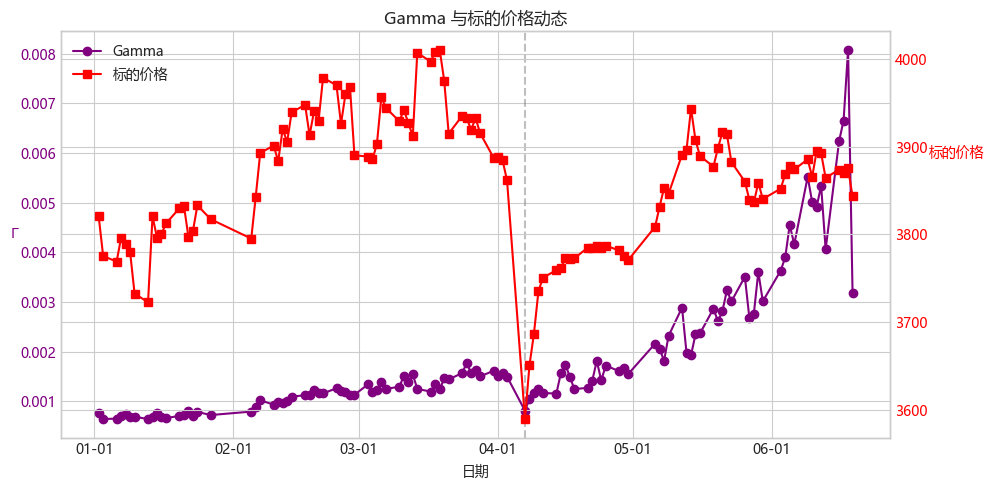

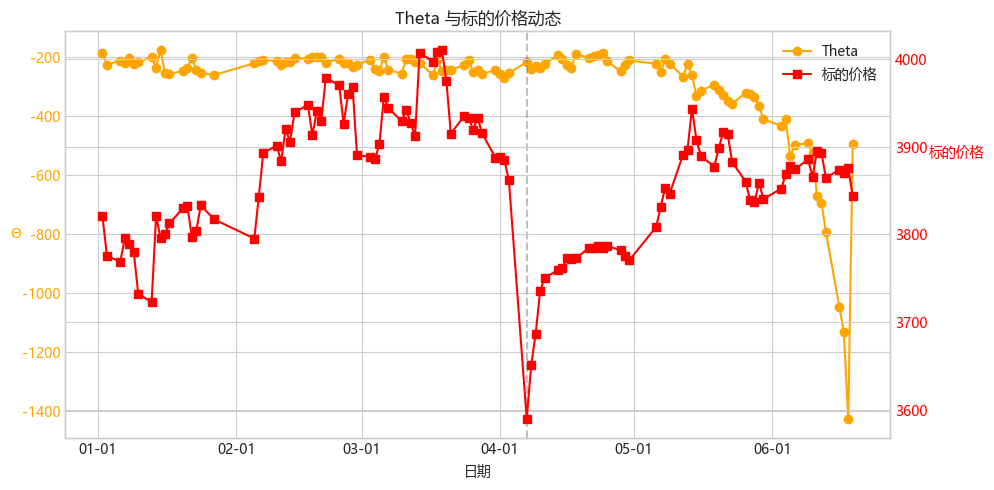

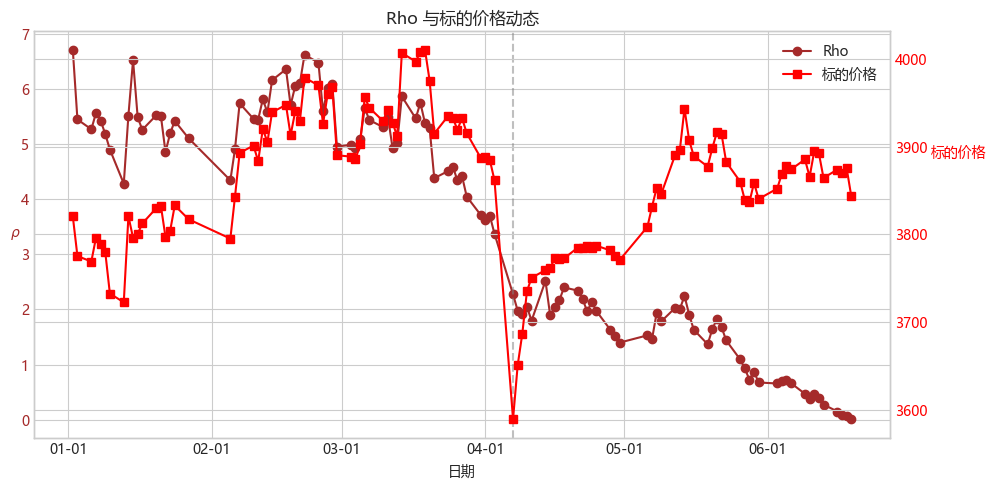

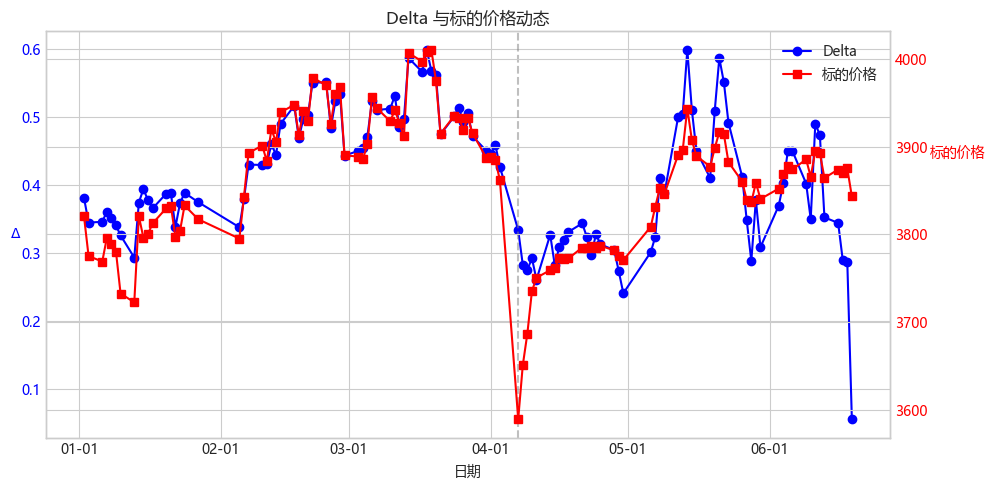

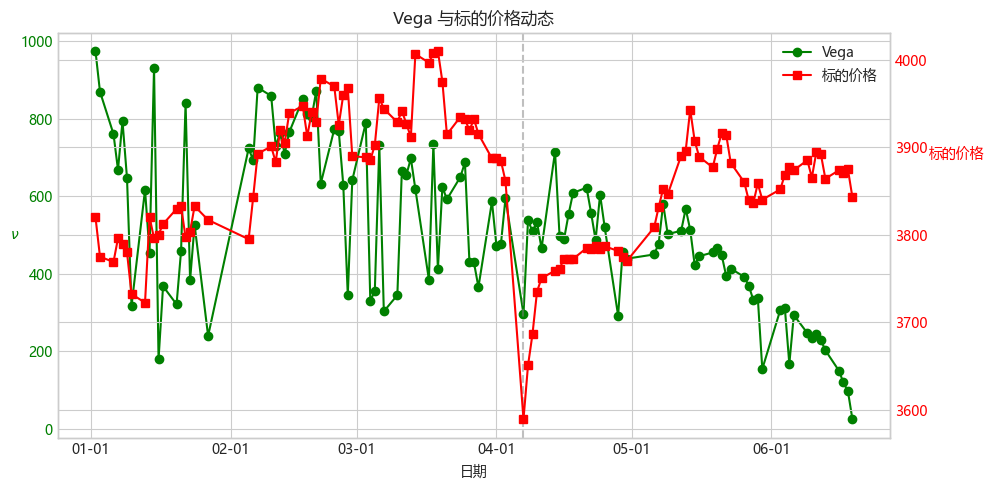

图表已生成，已剔除到期后无效数据。


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



# 剔除到期日后的数据
valid_df = greeks_df[(greeks_df['delta'] != 0)]

# 确保日期排序
valid_df = valid_df.sort_values('date')

def plot_greek_with_spot(df, greek_col, ylabel, color, filename, title_prefix=""):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(df['date'], df[greek_col], color=color, marker='o', label=f'{greek_col.capitalize()}')
    ax2.plot(df['date'], df['spot'], 'r-s', label='标的价格')
    
    ax1.axvline(pd.Timestamp('2025-04-07'), color='gray', linestyle='--', alpha=0.5)
    
    ax1.set_xlabel('日期')
    ax1.set_ylabel(ylabel, color=color, rotation=0, verticalalignment='center')
    ax2.set_ylabel('标的价格', color='r', rotation=0, verticalalignment='center')
    ax2.yaxis.set_label_coords(1.08, 0.7)
    ax1.tick_params(axis='y', labelcolor=color)
    ax2.tick_params(axis='y', labelcolor='r')
    
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.xticks(rotation=45)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='best')
    
    plt.title(f'{title_prefix}{greek_col.capitalize()} 与标的价格动态')
    plt.tight_layout()
    plt.savefig(f'../image/fig_{greek_col}_spot.pdf', dpi=300)
    plt.show()

plot_greek_with_spot(valid_df, 'gamma', '$\\Gamma$', 'purple', 'fig_gamma_spot.svg', title_prefix="")
plot_greek_with_spot(valid_df, 'theta', '$\\Theta$', 'orange', 'fig_theta_spot.svg')
plot_greek_with_spot(valid_df, 'rho', '$\\rho$', 'brown', 'fig_rho_spot.svg')
plot_greek_with_spot(valid_df, 'delta', '$\\Delta$', 'blue', 'fig_delta_spot.svg', title_prefix="")
plot_greek_with_spot(valid_df, 'vega', '$\\nu$', 'green', 'fig_vega_spot.svg', title_prefix="")
print("图表已生成，已剔除到期后无效数据。")

In [16]:
# 每日校准辅助信息 
print("\n" + "="*60)
print("生成附录 B：每日校准辅助信息")
print("="*60)

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates


# 准备存储每日信息的列表
daily_info = []

for idx, row in params_df.iterrows():
    eval_date = row['date'].to_pydatetime()
    print(f"处理日期: {eval_date.strftime('%Y-%m-%d')}")
    
    try:
        # 获取该日期的期权数据（计算隐含波动率后的有效期权）
        day_data = processor.calculate_implied_volatility(eval_date)
        if day_data.empty:
            print(f"  警告：{eval_date} 无期权数据，跳过")
            continue
        # 期权数量（成功计算 IV 的期权数）
        n_options = len(day_data)
        # 标的价格
        spot = processor.get_underlying_quote(eval_date)
        # 股息率
        div_yield = processor.get_dividend_yield(eval_date)
        
        # 平均剩余期限（用于计算代表性无风险利率）
        avg_T = day_data['T'].mean()
        # 无风险利率
        
        r = processor.get_risk_free_rate(avg_T, eval_date)
        
        # 从 params_df 中获取 RMSE 和 MAE
        rmse = row['rmse']
        mae = row['mae']
        
        daily_info.append({
            'date': eval_date.strftime('%Y-%m-%d'),
            'spot': spot,
            'n_options': n_options,
            'risk_free_rate': r,
            'dividend_yield': div_yield,
            'rmse': rmse,
            'mae': mae
        })
        
        print(f"  标的价格: {spot:.2f}, 期权数量: {n_options}, 平均T: {avg_T:.4f}, 利率: {r:.4%}, 股息率: {div_yield:.4%}, RMSE: {rmse:.2f}")
        
    except Exception as e:
        print(f"  处理失败: {e}")
        continue

appendix_b_df = pd.DataFrame(daily_info)

# 保存为 CSV
appendix_b_df.to_csv("appendix_B_daily_info.csv", index=False, encoding='utf-8-sig')
print("\n已保存附录 B CSV 文件: appendix_B_daily_info.csv")

# # 生成 LaTeX 表格代码
# latex_lines = []
# latex_lines.append("\\begin{longtable}{ccccccc}")
# latex_lines.append("\\caption{2025年每日校准辅助信息} \\\\")
# latex_lines.append("\\toprule")
# latex_lines.append("日期 & 标的价格(点) & 期权数量 & 无风险利率(\\%) & 股息率(\\%) & RMSE(点) & MAE(点) \\\\")
# latex_lines.append("\\midrule")
# latex_lines.append("\\endfirsthead")
# latex_lines.append("\\multicolumn{7}{c}{续表} \\\\")
# latex_lines.append("\\toprule")
# latex_lines.append("日期 & 标的价格(点) & 期权数量 & 无风险利率(\\%) & 股息率(\\%) & RMSE(点) & MAE(点) \\\\")
# latex_lines.append("\\midrule")
# latex_lines.append("\\endhead")
# latex_lines.append("\\bottomrule")
# latex_lines.append("\\endfoot")
# 
# for _, row in appendix_b_df.iterrows():
#     line = f"{row['date']} & {row['spot']:.2f} & {row['n_options']} & {row['risk_free_rate']*100:.2f} & {row['dividend_yield']*100:.2f} & {row['rmse']:.2f} & {row['mae']:.2f} \\\\"
#     latex_lines.append(line)
# 
# latex_lines.append("\\bottomrule")
# latex_lines.append("\\end{longtable}")
# 
# with open("appendix_B_daily_info.tex", "w", encoding='utf-8') as f:
#     f.write("\n".join(latex_lines))
# print("已保存附录 B LaTeX 代码: appendix_B_daily_info.tex")
# 
# # 显示前几行预览
# print("\n附录 B 预览：")
# print(appendix_b_df.to_string())


生成附录 B：每日校准辅助信息
处理日期: 2025-01-02
  标的价格: 3820.40, 期权数量: 122, 平均T: 0.2733, 利率: 0.9588%, 股息率: 3.6139%, RMSE: 9.11
处理日期: 2025-01-03
  标的价格: 3775.16, 期权数量: 112, 平均T: 0.2531, 利率: 1.5399%, 股息率: 3.6525%, RMSE: 11.28
处理日期: 2025-01-06
  标的价格: 3768.97, 期权数量: 106, 平均T: 0.2738, 利率: 1.5320%, 股息率: 3.6621%, RMSE: 7.66
处理日期: 2025-01-07
  标的价格: 3796.11, 期权数量: 83, 平均T: 0.2478, 利率: 1.5321%, 股息率: 3.6428%, RMSE: 5.78
处理日期: 2025-01-08
  标的价格: 3789.22, 期权数量: 94, 平均T: 0.2289, 利率: 1.1000%, 股息率: 3.6428%, RMSE: 7.68
处理日期: 2025-01-09
  标的价格: 3779.88, 期权数量: 67, 平均T: 0.2117, 利率: 1.1917%, 股息率: 3.6621%, RMSE: 7.40
处理日期: 2025-01-10
  标的价格: 3732.48, 期权数量: 56, 平均T: 0.2497, 利率: 1.6230%, 股息率: 3.7007%, RMSE: 8.94
处理日期: 2025-01-13
  标的价格: 3722.51, 期权数量: 82, 平均T: 0.2860, 利率: 1.4100%, 股息率: 3.7199%, RMSE: 9.27
处理日期: 2025-01-14
  标的价格: 3820.54, 期权数量: 88, 平均T: 0.2765, 利率: 1.3989%, 股息率: 3.6428%, RMSE: 7.34
处理日期: 2025-01-15
  标的价格: 3796.03, 期权数量: 55, 平均T: 0.2088, 利率: 1.8058%, 股息率: 3.6621%, RMSE: 7.28
处理日期: 2025-01-16
  标的价格: 3800

总记录数: 14759
日期范围: 2025-01-02 至 2025-12-31


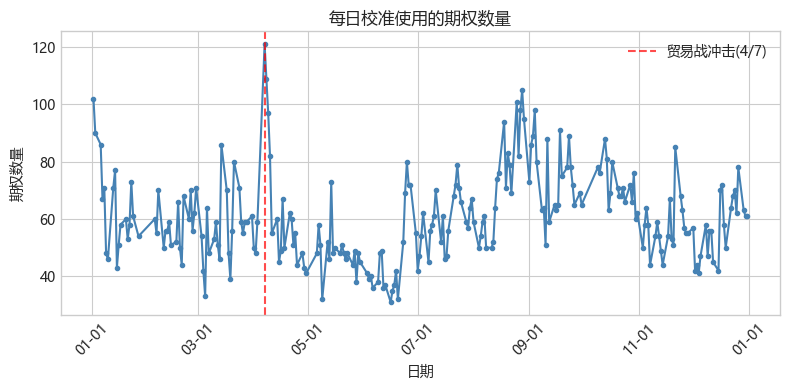

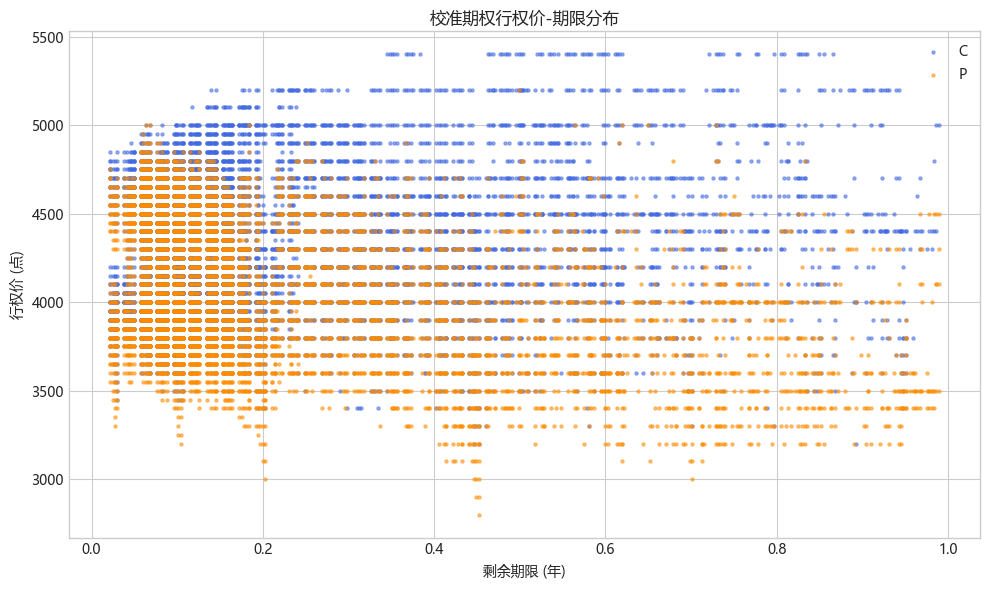

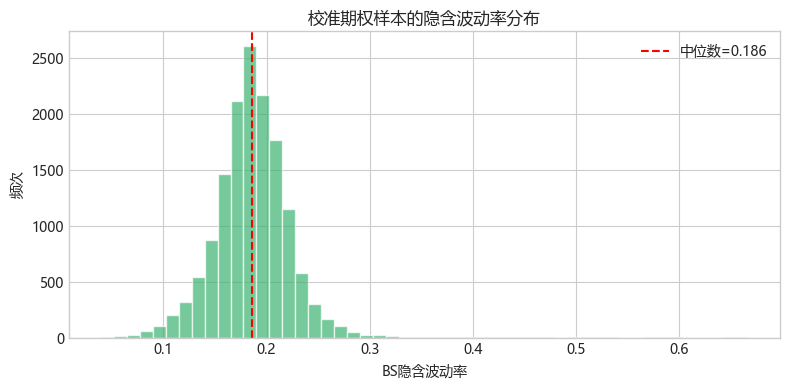

In [12]:
# 校准使用数据可视化
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

calib_df = pd.read_csv("calibration_options.csv", parse_dates=['date', 'expiry'],encoding="gbk")
# 计算剩余到期日（年）
if 'T' not in calib_df.columns:
    calib_df['T'] = (calib_df['expiry'] - calib_df['date']).dt.days / 365.0

print(f"总记录数: {len(calib_df)}")
print(f"日期范围: {calib_df['date'].min():%Y-%m-%d} 至 {calib_df['date'].max():%Y-%m-%d}")


# 每日期权数量走势

daily_counts = calib_df.groupby('date').size()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(daily_counts.index, daily_counts.values, marker='.', linestyle='-', color='steelblue')
ax.axvline(pd.Timestamp('2025-04-07'), color='red', linestyle='--', alpha=0.7, label='贸易战冲击(4/7)')
ax.set_xlabel('日期')
ax.set_ylabel('期权数量')
ax.set_title('每日校准使用的期权数量')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../image/calib_option_count.pdf", dpi=300, facecolor='white')
plt.show()


# 行权价与剩余期限散点图（按看涨/看跌着色）

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'C': 'royalblue', 'P': 'darkorange'}
for cp, color in colors.items():
    subset = calib_df[calib_df['cp'].str.upper().str.strip() == cp]
    ax.scatter(subset['T'], subset['strike'], c=color, label=f'{cp}', alpha=0.5, s=5)
ax.set_xlabel('剩余期限 (年)')
ax.set_ylabel('行权价 (点)')
ax.set_title('校准期权行权价-期限分布')
ax.legend()
plt.tight_layout()
plt.savefig("../image/calib_strike_T_scatter.pdf", dpi=300, facecolor='white')
plt.show()




# 隐含波动率分布直方图

if 'bs_iv' in calib_df.columns:
    iv_data = calib_df['bs_iv'].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(iv_data, bins=50, color='mediumseagreen', alpha=0.7, edgecolor='white')
    ax.axvline(iv_data.median(), color='red', linestyle='--', label=f'中位数={iv_data.median():.3f}')
    ax.set_xlabel('BS隐含波动率')
    ax.set_ylabel('频次')
    ax.set_title('校准期权样本的隐含波动率分布')
    ax.legend()
    plt.tight_layout()
    plt.savefig("../image/calib_bs_iv_hist.pdf", dpi=300, facecolor='white')
    plt.show()

图表已保存至 ..\image\CSI300_close_price.pdf


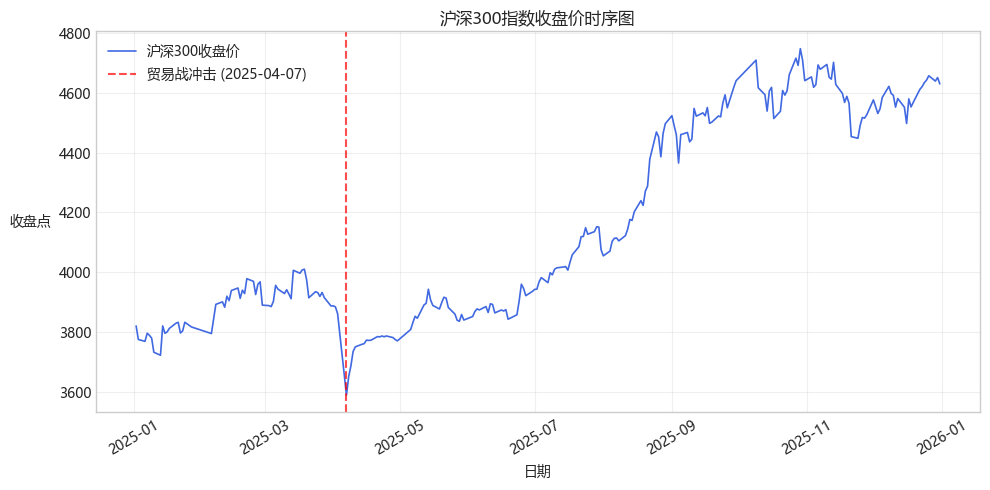

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 数据文件路径
csv_path = "../data/沪深300_股息率_市值加权_3年_20260408_024105.csv"


df = pd.read_csv(csv_path, parse_dates=['日期'])
df = df.sort_values('日期')
# 仅保留 2025 年数据
df = df[(df['日期'] >= '2025-01-01') & (df['日期'] <= '2025-12-31')]
if '收盘点位' not in df.columns:
    raise ValueError("CSV 文件中缺少 '收盘点位' 列")

close = df['收盘点位'].dropna()

# 创建图表
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['日期'], close, color='royalblue', linewidth=1.2, label='沪深300收盘价')

# 贸易战冲击日标记
ax.axvline(pd.Timestamp('2025-04-07'), color='red', linestyle='--', alpha=0.7, label='贸易战冲击 (2025-04-07)')

ax.set_xlabel('日期')
ax.set_ylabel('收盘点', rotation=0, verticalalignment='center',labelpad=20)
ax.set_title('沪深300指数收盘价时序图')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)

plt.tight_layout()

output_path = "..\\image\\CSI300_close_price.pdf"
plt.savefig(output_path, dpi=300, format='pdf', bbox_inches='tight', facecolor="white")
print(f"图表已保存至 {output_path}")

plt.show()

# 完结